# AI/R&D Assignment

## Problem Statement
We are given the parametric equations of a curve:
$$ x = t \cos(\theta) - e^{M|t|} \sin(0.3t) \sin(\theta) + X $$
$$ y = 42 + t \sin(\theta) + e^{M|t|} \sin(0.3t) \cos(\theta) $$

And a set of points $(x, y)$ that lie on this curve for some parameter $t \in (6, 60)$. We need to find the values of the unknown variables $\theta, M, X$.



## Mathematical Approach

To find the unknowns without knowing $t$ for each point, we can apply a rotational transformation to decouple the equations. Notice the trigonometric terms $\cos(\theta)$ and $\sin(\theta)$ acting as a rotation matrix.

Let's subtract the constants $X$ and $42$ from $x$ and $y$ respectively:
$$ x' = x - X = t \cos(\theta) - e^{M|t|} \sin(0.3t) \sin(\theta) $$
$$ y' = y - 42 = t \sin(\theta) + e^{M|t|} \sin(0.3t) \cos(\theta) $$

We can rotate the coordinate system by an angle $-\theta$ to define new coordinates $(u, v)$:
$$ u = x' \cos(\theta) + y' \sin(\theta) $$
$$ v = -x' \sin(\theta) + y' \cos(\theta) $$

Substituting the expressions for $x'$ and $y'$ into $u$ and $v$:
$$ u = (t \cos(\theta) - e^{M|t|} \sin(0.3t) \sin(\theta)) \cos(\theta) + (t \sin(\theta) + e^{M|t|} \sin(0.3t) \cos(\theta)) \sin(\theta) $$
$$ u = t (\cos^2\theta + \sin^2\theta) = t $$

$$ v = -(t \cos(\theta) - e^{M|t|} \sin(0.3t) \sin(\theta)) \sin(\theta) + (t \sin(\theta) + e^{M|t|} \sin(0.3t) \cos(\theta)) \cos(\theta) $$
$$ v = e^{M|t|} \sin(0.3t) (\sin^2\theta + \cos^2\theta) = e^{M|t|} \sin(0.3t) $$

Thus, the transformed coordinates $(u, v)$ have a very simple relationship:
$$ u = t $$
$$ v = e^{M|u|} \sin(0.3u) $$

This means that for every point $(x_i, y_i)$ in the dataset, if we guess the parameters $(\theta, M, X)$, we can compute $(u_i, v_i)$ and check how well they satisfy the equation $v_i = e^{M|u_i|} \sin(0.3u_i)$. 

We can frame this as an optimization problem where we minimize the Mean Squared Error (MSE) between the actual $v_i$ and the predicted $v_{pred, i} = e^{M|u_i|} \sin(0.3u_i)$.

## 1. Exploratory Data Analysis
Before jumping into solving for the parametric equation, let's first explore the provided dataset `xy_data.csv`. This will help us understand the distribution, bounds, and general shape of the points we need to fit.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize

# Load the dataset
df = pd.read_csv(r"D:\Downloads\flam\FlamApp-RnD-Assignment\data\xy_data.csv")
x_data = df['x'].values
y_data = df['y'].values


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1500 non-null   float64
 1   y       1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


In [13]:
df.describe()

,x,y
count,1500.000000,1500.000000
mean,83.713931,58.263519
std,13.697157,7.696524
min,59.657204,46.032295
25%,72.282910,51.124211
50%,84.710995,57.681288
75%,93.368257,66.138374
max,109.231520,69.685510


In [14]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1500, 2)


From the summary statistics, we observe the ranges of our $x$ and $y$ variables. Let's visualize the raw data to see the curve's structure. Since it is a parametric curve, the points should follow a specific trajectory.

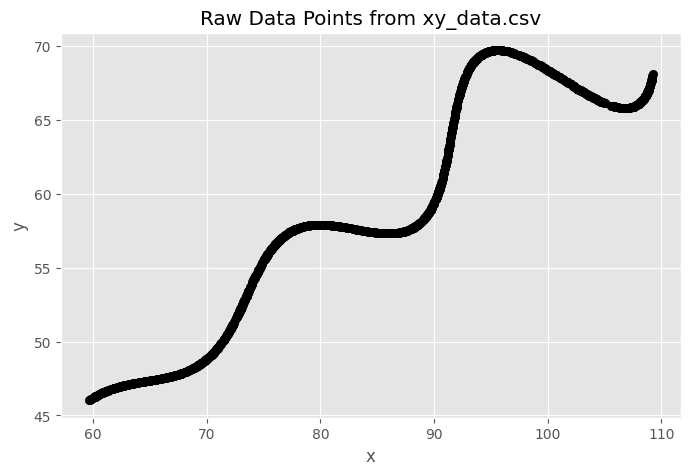

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, color='black')
plt.title('Raw Data Points from xy_data.csv')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
